# Monte Carlo Pricing of a European Call Option

This notebook prices a European call option using Monte Carlo simulation
under the risk-neutral measure.

Under the risk-neutral measure, the terminal asset price satisfies

\[
S_T = S_0 \exp\left[
\left(r-\frac{1}{2}\sigma^2\right)T
+\sigma\sqrt{T}Z
\right],
\qquad Z\sim N(0,1).
\]

The European call payoff at maturity is

\[
(S_T-K)^+ = \max(S_T-K,0).
\]

Therefore, its present value is

\[
C_0=e^{-rT}\mathbb{E}\left[(S_T-K)^+\right].
\]

Since the payoff depends only on \(S_T\), it is not necessary to simulate
the complete price path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def monte_carlo_call_price(
    S0, K, r, sigma, T, simulations, seed=None
):
    """Estimate a European call price using Monte Carlo simulation."""

    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(simulations)

    terminal_prices = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    payoffs = np.maximum(terminal_prices - K, 0)
    discounted_payoffs = np.exp(-r * T) * payoffs

    price = np.mean(discounted_payoffs)

    return price

In [2]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
simulations = 100_000

estimated_price = monte_carlo_call_price(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    simulations=simulations,
    seed=42
)

print(f"Monte Carlo call price: {estimated_price:.4f}")

Monte Carlo call price: 10.4205


## Black–Scholes benchmark

To evaluate the Monte Carlo estimate, we compare it with the
Black–Scholes analytical price:

\[
C_0=S_0N(d_1)-Ke^{-rT}N(d_2),
\]

where

\[
d_1=
\frac{\ln(S_0/K)+(r+\frac{1}{2}\sigma^2)T}
{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T}.
\]

Here, \(N(\cdot)\) denotes the standard normal cumulative distribution
function.

In [3]:
from scipy.stats import norm


def black_scholes_call_price(S0, K, r, sigma, T):
    """Calculate the Black-Scholes price of a European call."""

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    price = (
        S0 * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return price

In [4]:
bs_price = black_scholes_call_price(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T
)

absolute_error = abs(estimated_price - bs_price)
relative_error = absolute_error / bs_price

print(f"Monte Carlo price:  {estimated_price:.4f}")
print(f"Black-Scholes price: {bs_price:.4f}")
print(f"Absolute error:      {absolute_error:.4f}")
print(f"Relative error:      {relative_error:.4%}")

Monte Carlo price:  10.4205
Black-Scholes price: 10.4506
Absolute error:      0.0300
Relative error:      0.2875%


## Convergence analysis

By the law of large numbers, the Monte Carlo estimate should converge
to the Black–Scholes price as the number of simulations increases.

The typical Monte Carlo error decreases at the rate

\[
O\left(N^{-1/2}\right),
\]

where \(N\) is the number of simulations.

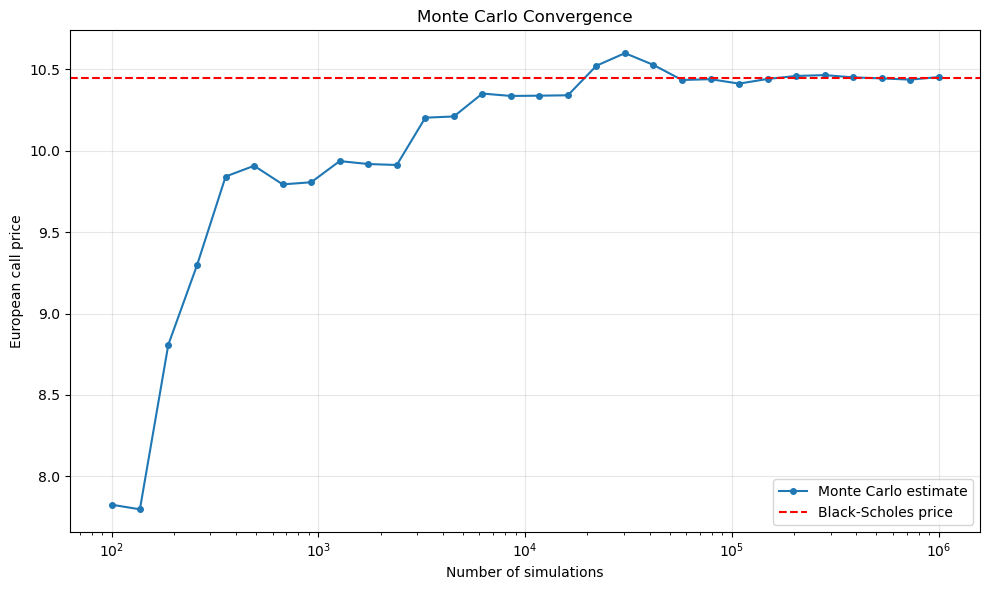

In [5]:
rng = np.random.default_rng(42)

max_simulations = 1_000_000
simulation_sizes = np.unique(
    np.logspace(2, 6, 30).astype(int)
)

Z = rng.standard_normal(max_simulations)

terminal_prices = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

discounted_payoffs = (
    np.exp(-r * T)
    * np.maximum(terminal_prices - K, 0)
)

cumulative_prices = (
    np.cumsum(discounted_payoffs)
    / np.arange(1, max_simulations + 1)
)

mc_estimates = cumulative_prices[simulation_sizes - 1]

plt.figure(figsize=(10, 6))

plt.plot(
    simulation_sizes,
    mc_estimates,
    marker="o",
    markersize=4,
    label="Monte Carlo estimate"
)

plt.axhline(
    bs_price,
    color="red",
    linestyle="--",
    label="Black-Scholes price"
)

plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("European call price")
plt.title("Monte Carlo Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confidence interval

The Monte Carlo estimator is a sample mean. Its standard error is
\(\mathrm{SE}=s/\sqrt{N}\), where \(s\) is the sample standard deviation
of the discounted payoffs.

An approximate 95% confidence interval is

\[
\widehat{C}_0 \pm 1.96\,\mathrm{SE}.
\]

In [6]:
def monte_carlo_call_with_confidence_interval(
    S0, K, r, sigma, T, simulations, seed=None
):
    """Estimate a European call price and its 95% confidence interval."""

    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(simulations)

    terminal_prices = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    discounted_payoffs = (
        np.exp(-r * T)
        * np.maximum(terminal_prices - K, 0)
    )

    price = np.mean(discounted_payoffs)
    standard_error = (
        np.std(discounted_payoffs, ddof=1)
        / np.sqrt(simulations)
    )

    lower_bound = price - 1.96 * standard_error
    upper_bound = price + 1.96 * standard_error

    return price, standard_error, lower_bound, upper_bound

In [7]:
(
    ci_price,
    standard_error,
    lower_bound,
    upper_bound
) = monte_carlo_call_with_confidence_interval(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    simulations=100_000,
    seed=42
)

print(f"Monte Carlo price: {ci_price:.4f}")
print(f"Standard error:    {standard_error:.4f}")
print(
    f"95% confidence interval: "
    f"[{lower_bound:.4f}, {upper_bound:.4f}]"
)
print(f"Black-Scholes price: {bs_price:.4f}")

Monte Carlo price: 10.4205
Standard error:    0.0468
95% confidence interval: [10.3289, 10.5122]
Black-Scholes price: 10.4506


## Conclusion

Using 100,000 simulations, the Monte Carlo estimate was \(10.4205\),
compared with the Black–Scholes benchmark of \(10.4506\).

The analytical price lies within the estimated 95% confidence interval,
\([10.3289, 10.5122]\). The convergence plot also shows that the Monte
Carlo estimate becomes more stable as the sample size increases.

The remaining difference is consistent with ordinary Monte Carlo
sampling error.